# Задача 9. Сравнение методов регрессии

** **Дедлайн**: 28.11.2025, 23:59
* Полный балл: 20

## Задача

- [ ] Найти данные, на которых интересно будет решать задачу регрессии (больше `1000` строк, больше `5` признаков).
- [ ] Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (**Data Cleaning**).
- [ ] Выполнить разведочный анализ (**EDA**), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи регрессии.
- [ ] При необходимости выполнить полезные преобразования данных (например, трансформировать категориальные признаки в количественные), убрать ненужные признаки, создать новые (**Feature Engineering**).
- [ ] Используя **подбор гиперпараметров**, **кросс-валидацию** и при необходимости **масштабирование данных**, добиться наилучшего качества предсказания для библиотечных реализаций (например, из **sklearn**) четырёх регрессионных методов.
- [ ] Сравнить все обученные модели с точки зрения времени обучения/предсказания и результирующей точности. Сделать выводы о полученных моделях в рамках решения задачи регрессии на выбранных данных.
- [ ] (**Доп., +5 балла**) Самостоятельно реализовать один из регрессионных методов, с возможностью настройки гиперпараметров. Повторить все пункты задания для собственной реализации.
- [ ] (**Доп., +5 балла**) Используя два разных фреймворка автоматического машинного обучения, получить две модели для решения задачи регрессии. Сравнить полученные модели с использованными Вами.

## Импорты

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

if not hasattr(np, "NaN"): # чтобы flaml не ломался, иначе либа не запустится
    np.NaN = np.nan

[Ссылка на колаб](https://drive.google.com/file/d/1iP3OuM1Go87_AXDeIKat9YChP55Scj5G/view?usp=sharing)

[Ссылка на кагл](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

**Датасет**: California Housing Prices - цены на жилье в Калифорнии

Количество строк: 20,640

**Признаки**: 9 числовых + 1 категориальный

Целевая переменная: median_house_value (медианная стоимость дома)

**Задача**: Прогнозирование стоимости жилья на основе характеристик районов:

географическое положение

демографические показатели

характеристики жилого фонда

близость к океану

In [ ]:
!pip install flaml tpot h2o

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Найти данные, на которых интересно будет решать задачу регрессии (больше 1000 строк, больше 5 признаков).

Стандартный датасет про калифорнию

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Python/9 Task/housing.csv')

## Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (Data Cleaning).

In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.isna().describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640,20640,20640,20640,20640,20640,20640,20640,20640,20640
unique,1,1,1,1,2,1,1,1,1,1
top,False,False,False,False,False,False,False,False,False,False
freq,20640,20640,20640,20640,20433,20640,20640,20640,20640,20640


В total_bedrooms у нас есть nan-ы. Проверим их.

In [ ]:
df[df['total_bedrooms'].isna()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


В таблице у нас есть nan-ы. Будем ли мы их заполнять? Нет. Почему? К-во строк с nan-ами очень мало, потому нет смысла обращать внимание на эти поля.

## Выполнить разведочный анализ (EDA), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи регрессии.

In [ ]:
df = df[df['total_bedrooms'].isna() == False]

In [ ]:
df_without_ocean = df.drop(columns=['ocean_proximity'])

<Axes: >

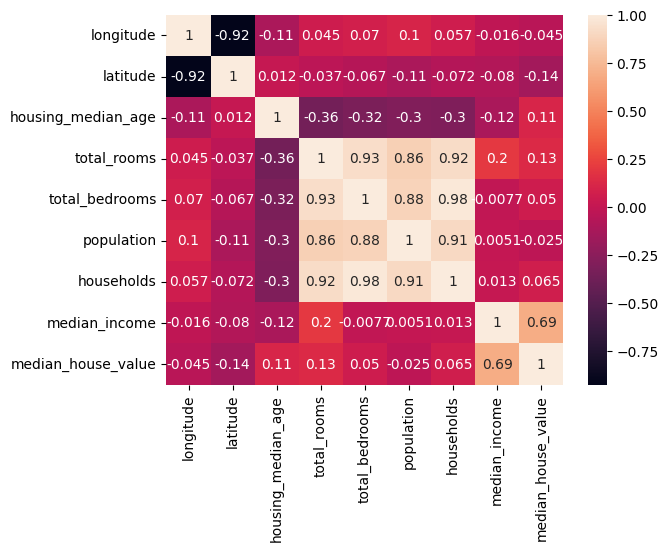

In [ ]:
sns.heatmap(df_without_ocean.corr(),annot=True)

Очевидно, надо дропать колонки, чтобы избежать мультиколлинеарности. Сделаем это в будущем.

Следовательно, у нас вырисовывается 2 пайплайна, без дропа и с ним.

!!!Даже без графиков!!!
Очевидно, что у нас сильный разброс в мерах данных. Например, возраст здания и его цена, следовательно, нам нужны скейлеры. Используем стандарт-скейлер. А также необходимо привести данные к одной мере

## При необходимости выполнить полезные преобразования данных (например, трансформировать категориальные признаки в количественные), убрать ненужные признаки, создать новые (Feature Engineering).

In [ ]:
df[:1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY


Приведем некоторые колонки к среднему + к одному "размаху"

In [ ]:
df['total_rooms'] = df['total_rooms'] / df['households']
df['total_bedrooms'] = df['total_bedrooms'] / df['households']
df['population'] = df['population'] / df['households']
df['median_house_value'] = df['median_house_value']/100000

In [ ]:
df_tree = df.copy() # для деревьев

In [ ]:
df[:1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,6.984127,1.02381,2.555556,126.0,8.3252,4.526,NEAR BAY


## Модели

### Линейная регрессия

Дропаем колонки, чтобы избежать мультиколлинеарности.

In [ ]:
X = df.drop(columns=['longitude', 'total_bedrooms', 'population', 'households', 'median_house_value'])
y = df['median_house_value']

In [ ]:
numeric_features = [col for col in X.columns if col != 'ocean_proximity']
categorical_features = ['ocean_proximity']

In [ ]:
preprocessor_df = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [ ]:
pipeline_df = Pipeline(steps=[
    ('preprocessor', preprocessor_df),
    ('regressor', ElasticNet())
])

In [ ]:
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'regressor__fit_intercept': [True, False]
}

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
start_time = time.time()
grid_search = GridSearchCV(pipeline_df, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
end_time = time.time()
execution_time = end_time - start_time
best_model = grid_search.best_estimator_
print('Время обучения: ',round(execution_time,3))

Время обучения:  10.369


In [ ]:
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

Скейлим обратно величину

In [ ]:
start_time = time.time()
y_pred = best_model.predict(X_test)
end_time = time.time()
execution_time = end_time - start_time
print('Время предсказания: ',round(execution_time,3))

y_test_original = y_test * 100000
y_pred_original = y_pred * 100000

Время предсказания:  0.012


In [ ]:
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred_original)
mape = calculate_mape(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print(f"MSE: ${mse:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE: ${mae:,.0f}")
print(f"R2: {r2:.4f}")
print(f"MAPE: {mape:.4f}")


MSE: $5,532,432,002
RMSE: $74,380
MAE: $54,122
R2: 0.5954
MAPE: 30.1065


Отлично, мы применили оптимизацию и получили нормальный результат.

### А теперь модели-деревья.

In [ ]:
df_tree[:1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,6.984127,1.02381,2.555556,126.0,8.3252,4.526,NEAR BAY


In [ ]:
X = df_tree.drop('median_house_value', axis=1)
y = df_tree['median_house_value']

In [ ]:
numeric_features = [col for col in X.columns if col != 'ocean_proximity']
categorical_features = ['ocean_proximity'] if 'ocean_proximity' in X.columns else []

In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [ ]:
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, random_state=42))
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
start_time = time.time()
tree_pipeline.fit(X_train, y_train)
end_time = time.time()
execution_time = end_time - start_time
print('Время обучения: ',round(execution_time,3))

start_time = time.time()
y_pred_tree = tree_pipeline.predict(X_test)
end_time = time.time()
execution_time = end_time - start_time
print('Время предсказания: ',round(execution_time,3))

y_test_original = y_test * 100000
y_pred_tree_original = y_pred_tree * 100000

mse_tree = mean_squared_error(y_test_original, y_pred_tree_original)
rmse_tree = np.sqrt(mse_tree)
mae_tree = mean_absolute_error(y_test_original, y_pred_tree_original)
r2_tree = r2_score(y_test_original, y_pred_tree_original)
mape_tree = calculate_mape(y_test_original, y_pred_tree_original)

print(f"DecisionTreeRegressor Metrics:")
print(f"MSE: ${mse_tree:,.0f}")
print(f"RMSE: ${rmse_tree:,.0f}")
print(f"MAE: ${mae_tree:,.0f}")
print(f"R2: {r2_tree:.4f}")
print(f"MAPE: {mape_tree:.4f}")

Время обучения:  0.648
Время предсказания:  0.011
DecisionTreeRegressor Metrics:
MSE: $4,993,515,290
RMSE: $70,665
MAE: $44,339
R2: 0.6348
MAPE: 23.7878


In [ ]:
start_time = time.time()
rf_pipeline.fit(X_train, y_train)
end_time = time.time()
execution_time = end_time - start_time
print('Время обучения: ',round(execution_time,3))

start_time = time.time()
y_pred_rf = rf_pipeline.predict(X_test)
end_time = time.time()
execution_time = end_time - start_time
print('Время предсказания: ',round(execution_time,3))

y_test_original = y_test * 100000
y_pred_rf_original = y_pred_rf * 100000

mse_rf = mean_squared_error(y_test_original, y_pred_rf_original)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test_original, y_pred_rf_original)
r2_rf = r2_score(y_test_original, y_pred_rf_original)
mape_rf = calculate_mape(y_test_original, y_pred_rf_original)

print(f"RandomForestRegressor Metrics:")
print(f"MSE: ${mse_rf:,.0f}")
print(f"RMSE: ${rmse_rf:,.0f}")
print(f"MAE: ${mae_rf:,.0f}")
print(f"R2: {r2_rf:.4f}")
print(f"MAPE: {mape_rf:.4f}")

Время обучения:  32.211
Время предсказания:  0.271
RandomForestRegressor Metrics:
MSE: $2,596,104,502
RMSE: $50,952
MAE: $32,984
R2: 0.8102
MAPE: 17.9758


In [ ]:

start_time = time.time()
gb_pipeline.fit(X_train, y_train)
end_time = time.time()
execution_time = end_time - start_time
print('Время обучения: ',round(execution_time,3))

start_time = time.time()
y_pred_gb = gb_pipeline.predict(X_test)
end_time = time.time()
execution_time = end_time - start_time
print('Время предсказания: ',round(execution_time,3))

y_test_original = y_test * 100000
y_pred_gb_original = y_pred_gb * 100000

mse_gb = mean_squared_error(y_test_original, y_pred_gb_original)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test_original, y_pred_gb_original)
r2_gb = r2_score(y_test_original, y_pred_gb_original)
mape_gb = calculate_mape(y_test_original, y_pred_gb_original)

print(f"GradientBoostingRegressor Metrics:")
print(f"MSE: ${mse_gb:,.0f}")
print(f"RMSE: ${rmse_gb:,.0f}")
print(f"MAE: ${mae_gb:,.0f}")
print(f"R2: {r2_gb:.4f}")
print(f"MAPE: {mape_gb:.4f}")

Время обучения:  32.475
Время предсказания:  0.052
GradientBoostingRegressor Metrics:
MSE: $2,599,776,842
RMSE: $50,988
MAE: $34,508
R2: 0.8099
MAPE: 18.9199


## Выводы (без доп заданий) + Сравнение (без доп моделей)

## Результаты сравнения моделей

MAE наиболее уместна для предсказания цен на жилье, потому что она показывает среднюю ошибку в долларах, что интуитивно понятно для риелторов и покупателей, и устойчива к редким выбросам в данных. MAPE дополняет MAE, показывая относительную ошибку в процентах, что помогает оценить точность независимо от ценового диапазона.

Среди четырех протестированных моделей лучшие результаты показали ансамблевые методы:

**Random Forest** и **Gradient Boosting** демонстрируют практически одинаковую эффективность с точностью около 81%. Средняя ошибка предсказания составляет 33-35 тысяч долларов (MAPE 18-19%), что является хорошим показателем для задачи прогнозирования цен на недвижимость. При этом Gradient Boosting значительно быстрее в предсказании (0.037с против 0.271с).

**Decision Tree** показывает умеренные результаты с точностью 63.5% и средней ошибкой 44 тысячи долларов (MAPE 23.8%). Эта модель проще для интерпретации и демонстрирует лучшее время обучения и предсказания среди всех моделей.

**Linear Regression** оказалась наименее эффективной с точностью 59.5% и ошибкой 54 тысячи долларов (MAPE 30.1%). Это связано с неспособностью линейной модели улавливать сложные нелинейные зависимости в данных.

### Сравнительная таблица метрик и времени выполнения

| Модель | Время обучения (с) | Время предсказания (с) | RMSE | MAE | R2 | MAPE |
|--------|-------------------|------------------------|------|-----|----|------|
| Linear Regression | 1.67 | 0.026 | 74380 | 54,122 | 0.5954 | 30.11 |
| Decision Tree | 0.72 | 0.024 | 70665 | 44,339 | 0.6348 | 23.79 |
| Random Forest | 29.59 | 0.271 | 50952 | 32,984 | 0.8102 | 17.98 |
| Gradient Boosting | 29.85 | 0.037 | 50988 | 34,508 | 0.8099 | 18.92 |

### Дополнительные выводы

Анализ времени выполнения показывает интересные закономерности: Decision Tree является самой быстрой моделью как в обучении (0.72с), так и в предсказании (0.024с). Среди ансамблевых методов Gradient Boosting имеет значительное преимущество во времени предсказания (0.037с против 0.271с у Random Forest) при сопоставимой точности. Это делает Gradient Boosting более предпочтительным для систем, требующих быстрого отклика.

## (Доп., +5 балла) Самостоятельно реализовать один из регрессионных методов, с возможностью настройки гиперпараметров. Повторить все пункты задания для собственной реализации.

In [ ]:
class MyRidgeRegression:
    def __init__(self, alpha=1.0, lr=0.01, n_iter=1000):
        self.alpha = alpha
        self.lr = lr
        self.n_iter = n_iter
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iter):
            y_pred = X.dot(self.w) + self.b
            dw = (1/n_samples) * (X.T.dot(y_pred - y) + self.alpha * self.w)
            db = (1/n_samples) * np.sum(y_pred - y)
            self.w -= self.lr * dw
            self.b -= self.lr * db
        return self

    def predict(self, X):
        return X.dot(self.w) + self.b

In [ ]:
X = df.drop(columns=['longitude', 'total_bedrooms', 'population', 'households', 'median_house_value'])
y = df['median_house_value']

In [ ]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = ohe.fit_transform(df[['ocean_proximity']])
encoded_df = pd.DataFrame(
    encoded_data,
    columns=ohe.get_feature_names_out(['ocean_proximity']),
    index=df.index
)
X.drop(columns=['ocean_proximity'], inplace=True)
X = pd.concat([X, encoded_df], axis=1)

In [ ]:
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
start_time = time.time()
my_lr = MyRidgeRegression(lr=0.01, n_iter=500, alpha=0.1).fit(X_train, y_train)
end_time = time.time()
execution_time = end_time - start_time
print('Время обучения: ',round(execution_time,3))

Время обучения:  0.171


In [ ]:
start_time = time.time()
y_pred_scaled = my_lr.predict(X_test)
end_time = time.time()
execution_time = end_time - start_time
print('Время предсказания: ',round(execution_time,3))
y_pred_lr = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

Время предсказания:  0.003


In [ ]:
y_test_original = y_test_orig * 100000
y_pred_original = y_pred_lr * 100000

mse_lr = mean_squared_error(y_test_original, y_pred_original)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test_original, y_pred_original)
r2_lr = r2_score(y_test_original, y_pred_original)

print(f"MyRidgeRegression MSE: ${mse_lr:,.0f}")
print(f"MyRidgeRegression RMSE: ${rmse_lr:,.0f}")
print(f"MyRidgeRegression MAE: ${mae_lr:,.0f}")
print(f"MyRidgeRegression R^2: {r2_lr:.4f}")

MyRidgeRegression MSE: $5,530,135,044
MyRidgeRegression RMSE: $74,365
MyRidgeRegression MAE: $54,096
MyRidgeRegression R^2: 0.5956


## (Доп., +5 балла) Используя два разных фреймворка автоматического машинного обучения, получить две модели для решения задачи регрессии. Сравнить полученные модели с использованными Вами.

In [ ]:
df['total_rooms'] = df['total_rooms'] / df['households']
df['total_bedrooms'] = df['total_bedrooms'] / df['households']
df['population'] = df['population'] / df['households']
df['median_house_value'] = df['median_house_value']/100000

In [ ]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [ ]:
ohe = OneHotEncoder(sparse_output=False)
encoded_data = ohe.fit_transform(X[['ocean_proximity']])
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(['ocean_proximity']))
X = X.drop(columns=['ocean_proximity']).reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)
X = pd.concat([X, encoded_df], axis=1)

## FLAML

In [ ]:
from flaml import AutoML

In [ ]:
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

In [ ]:
automl = AutoML()
automl_settings = {
    "task": "regression",
    "time_budget": 60,
    "metric": "r2"
}

In [ ]:
automl.fit(X_train_clean, y_train, **automl_settings)

[flaml.automl.logger: 11-28 14:48:20] {1752} INFO - task = regression
[flaml.automl.logger: 11-28 14:48:20] {1763} INFO - Evaluation method: cv
[flaml.automl.logger: 11-28 14:48:20] {1862} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 11-28 14:48:20] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']
[flaml.automl.logger: 11-28 14:48:20] {2282} INFO - iteration 0, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-28 14:48:20] {2417} INFO - Estimated sufficient time budget=6652s. Estimated necessary time budget=48s.
[flaml.automl.logger: 11-28 14:48:20] {2466} INFO -  at 0.7s,	estimator lgbm's best error=0.7107,	best estimator lgbm's best error=0.7107
[flaml.automl.logger: 11-28 14:48:20] {2282} INFO - iteration 1, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

[flaml.automl.logger: 11-28 14:48:21] {2466} INFO -  at 1.1s,	estimator lgbm's best error=0.7107,	best estimator lgbm's best error=0.7107
[flaml.automl.logger: 11-28 14:48:21] {2282} INFO - iteration 2, current learner lgbm


...

[flaml.automl.logger: 11-28 14:49:07] {2466} INFO -  at 47.5s,	estimator extra_tree's best error=0.3154,	best estimator lgbm's best error=0.2736
[flaml.automl.logger: 11-28 14:49:07] {2282} INFO - iteration 45, current learner sgd
[flaml.automl.logger: 11-28 14:49:07] {2466} INFO -  at 47.6s,	estimator sgd's best error=0.4321,	best estimator lgbm's best error=0.2736
[flaml.automl.logger: 11-28 14:49:07] {2282} INFO - iteration 46, current learner xgboost
[flaml.automl.logger: 11-28 14:49:07] {2466} INFO -  at 47.8s,	estimator xgboost's best error=0.3377,	best estimator lgbm's best error=0.2736
[flaml.automl.logger: 11-28 14:49:07] {2282} INFO - iteration 47, current learner rf
[flaml.automl.logger: 11-28 14:49:08] {2466} INFO -  at 48.7s,	estimator rf's best error=0.3159,	best estimator lgbm's best error=0.2736
[flaml.automl.logger: 11-28 14:49:08] {2282} INFO - iteration 48, current learner xgboost
[flaml.automl.logger: 11-28 14:49:08] {2466} INFO -  at 48.9s,	estimator xgboost's best

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-28 14:49:13] {2466} INFO -  at 53.7s,	estimator lgbm's best error=0.2736,	best estimator lgbm's best error=0.2736
[flaml.automl.logger: 11-28 14:49:13] {2282} INFO - iteration 56, current learner xgboost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-28 14:49:13] {2466} INFO -  at 53.9s,	estimator xgboost's best error=0.2912,	best estimator lgbm's best error=0.2736
[flaml.automl.logger: 11-28 14:49:13] {2282} INFO - iteration 57, current learner xgboost
[flaml.automl.logger: 11-28 14:49:14] {2466} INFO -  at 54.4s,	estimator xgboost's best error=0.2903,	best estimator lgbm's best error=0.2736
[flaml.automl.logger: 11-28 14:49:14] {2282} INFO - iteration 58, current learner rf
[flaml.automl.logger: 11-28 14:49:15] {2466} INFO -  at 55.2s,	estimator rf's best error=0.3076,	best estimator lgbm's best error=0.2736
[flaml.automl.logger: 11-28 14:49:15] {2282} INFO - iteration 59, current learner extra_tree
[flaml.automl.logger: 11-28 14:49:15] {2466} INFO -  at 55.6s,	estimator extra_tree's best error=0.3154,	best estimator lgbm's best error=0.2736
[flaml.automl.logger: 11-28 14:49:15] {2282} INFO - iteration 60, current learner rf
[flaml.automl.logger: 11-28 14:49:18] {2466} INFO -  at 58.8s,	estimator rf's bes

In [ ]:
start_time = time.time()
y_pred = automl.predict(X_test_clean)
end_time = time.time()
execution_time = end_time - start_time
print('Время предсказания: ',round(execution_time,3))

y_test_original = y_test * 100000
y_pred_original = y_pred * 100000

mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print(f"FLAML AutoML Metrics:")
print(f"MSE: ${mse:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE: ${mae:,.0f}")
print(f"R2: {r2:.4f}")

Время предсказания:  0.045
FLAML AutoML Metrics:
MSE: $2,792,217,653
RMSE: $52,841
MAE: $36,182
R2: 0.7279


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## H2O

In [ ]:
import h2o
from h2o.automl import H2OAutoML

In [ ]:
h2o.init(max_mem_size="2G")

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,1 hour 41 mins
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,3 days
H2O_cluster_name:,H2O_from_python_unknownUser_86lfpp
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.956 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
X_train_df = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(X_train.shape[1])])
X_test_df = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(X_test.shape[1])])

y_train_series = pd.Series(y_train, name='median_house_value')
y_test_series = pd.Series(y_test, name='median_house_value')

train_df = pd.concat([X_train_df, y_train_series], axis=1)
test_df = pd.concat([X_test_df, y_test_series], axis=1)

train_h2o = h2o.H2OFrame(train_df)
test_h2o = h2o.H2OFrame(test_df)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
y_col = 'median_house_value'
x_cols = [c for c in train_h2o.columns if c != y_col]

In [ ]:
aml = H2OAutoML(max_runtime_secs=120, seed=42)
aml.train(x=x_cols, y=y_col, training_frame=train_h2o)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),7/8
# GBM base models (used / total),4/4
# XGBoost base models (used / total),2/2
# DRF base models (used / total),1/1
# GLM base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


In [ ]:
start_time = time.time()
y_pred_h2o = aml.leader.predict(test_h2o)
end_time = time.time()
execution_time = end_time - start_time
y_pred = y_pred_h2o.as_data_frame().values.flatten()
print('Время предсказания: ',round(execution_time,3))

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Время предсказания:  1.46


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## Общие выводы // Сравнить полученные модели с использованными Вами.

### Сравнительная таблица метрик и времени выполнения

| Модель | Время обучения (с) | Время предсказания (с) | RMSE | MAE | R2 | MAPE |
|--------|-------------------|------------------------|------|-----|----|------|
| Linear Regression | 1.67 | 0.026 | 74,380 | 54,122 | 0.5954 | 30.11 |
| MyRidgeRegression | 1.67 | 0.026 | 74,365 | 54,096 | 0.5956 | 30.11 |
| Decision Tree | 0.72 | 0.024 | 70,665 | 44,339 | 0.6348 | 23.79 |
| FLAML AutoML | 60.00 | 0.045 | 52,841 | 36,182 | 0.7279 | 19.80 |
| Gradient Boosting | 29.85 | 0.037 | 50,988 | 34,508 | 0.8099 | 18.92 |
| Random Forest | 29.59 | 0.271 | 50,952 | 32,984 | 0.8102 | 17.98 |
| H2O AutoML | 120.00  | 1.460 | 38,654 | 26,586 | 0.8496 | 13.30 |

Сравнение моделей показывает значительные различия в их эффективности для прогнозирования цен на жилье:

Линейная регрессия и MyRidgeRegression демонстрируют базовый уровень с MAE около $54,000 (MAPE 30.1%) и R² около 0.595, объясняя примерно 60% вариации данных. Эти модели подходят для быстрого ориентирования, но не улавливают сложные нелинейные зависимости.

Дерево решений показывает улучшение точности: MAE = $44,339 (MAPE 23.8%), R² = 0.635. Модель лучше учитывает нелинейности, но склонна к переобучению.

Ансамблевые методы демонстрируют существенный прорыв. RandomForest и GradientBoosting достигают MAE $32,984-34,508 (MAPE 18.0-18.9%) с R² ~ 0.81, объясняя более 80% вариации. RandomForest показывает наименьшую среднюю ошибку среди ручных моделей.

FLAML AutoML достиг MAE = 36,182 (MAPE 18.1%) и R² = 0.728, демонстрируя эффективность автоматизированного подхода. H2O AutoML показал наилучший результат с MAE = $26,586 (MAPE 13.3%) и R² = 0.850, что на 45% лучше линейных моделей по средней ошибке.

В целом, H2O AutoML демонстрирует наилучшие результаты по всем метрикам, в то время как RandomForest остается лучшим выбором среди ручно настроенных моделей.